# STO-MILP v10 — Results Figures

Visualizations for the 8-case experimental matrix and bridge v1 vs v7 comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150, 'font.size': 10})
out = Path('../milp_outputs')
out.mkdir(exist_ok=True)

# Load data
cases = pd.read_csv(out / 'case_summary_main.csv')
bridge = pd.read_csv(out / 'bridge_comparison.csv')
print(f'Cases: {len(cases)} rows')
print(f'Bridge comparison: {len(bridge)} rows')

Cases: 8 rows
Bridge comparison: 2 rows


## Figure 1 — Total Annual Cost by Case

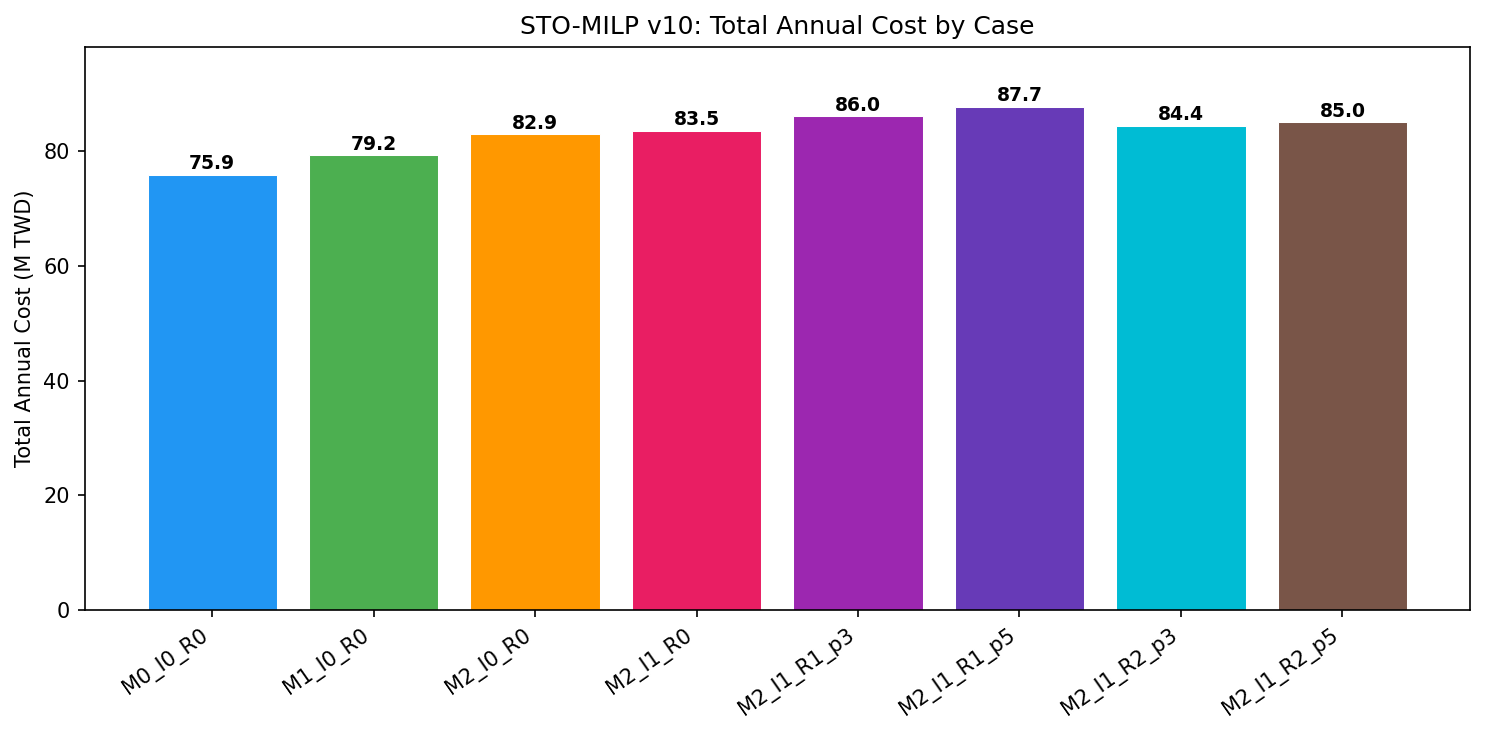

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#673AB7', '#00BCD4', '#795548']
bars = ax.bar(cases['case'], cases['total_cost_M'], color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, cases['total_cost_M']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Total Annual Cost (M TWD)')
ax.set_title('STO-MILP v10: Total Annual Cost by Case')
ax.set_ylim(0, cases['total_cost_M'].max() * 1.12)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(out / 'fig1_total_cost_by_case.png')
plt.show()

## Figure 2 — Investment vs Operating Cost Breakdown

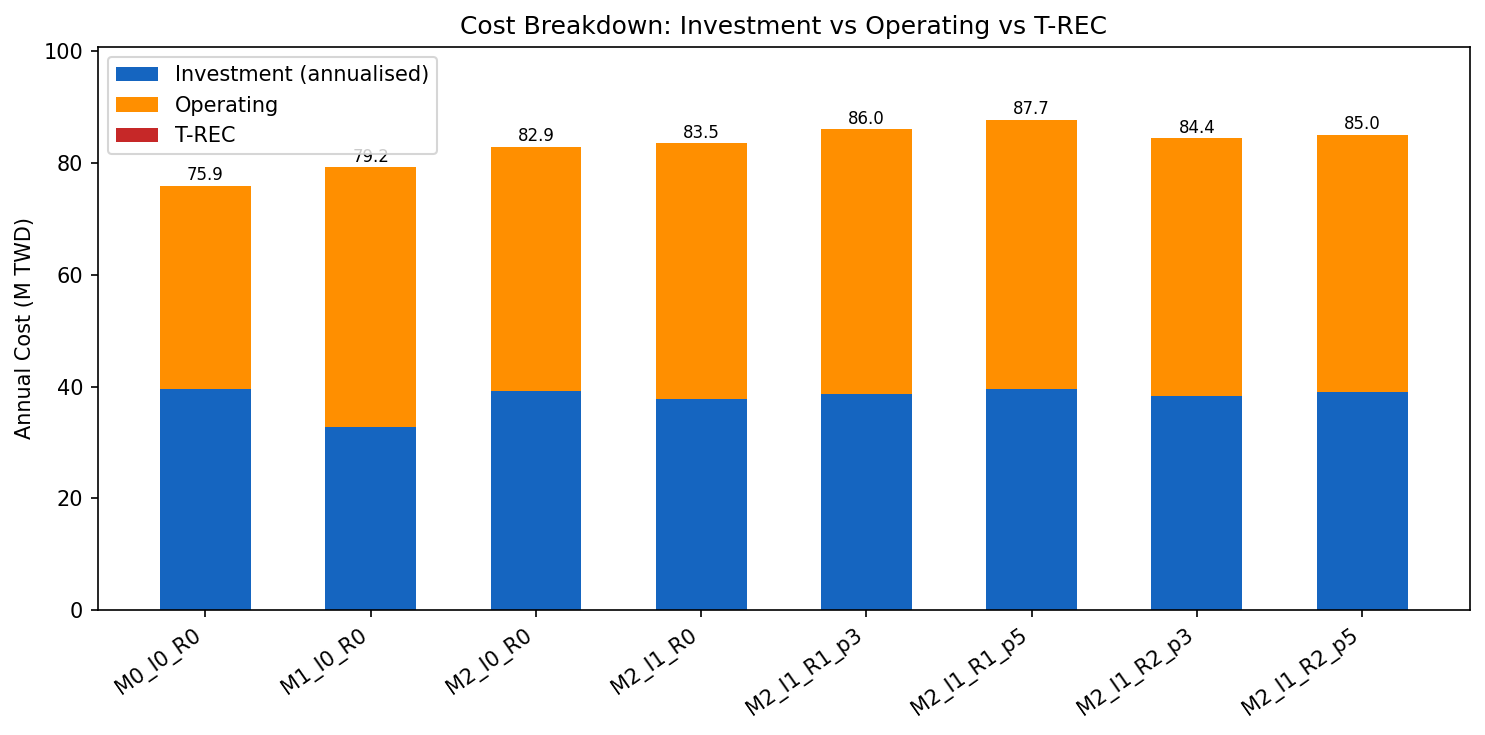

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cases))
w = 0.55
ax.bar(x, cases['invest_M'], w, label='Investment (annualised)', color='#1565C0')
ax.bar(x, cases['opex_M'], w, bottom=cases['invest_M'], label='Operating', color='#FF8F00')
ax.bar(x, cases['trec_M'], w, bottom=cases['invest_M'] + cases['opex_M'], label='T-REC', color='#C62828')
for i, row in cases.iterrows():
    ax.text(i, row['total_cost_M'] + 0.3, f"{row['total_cost_M']:.1f}",
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(cases['case'], rotation=35, ha='right')
ax.set_ylabel('Annual Cost (M TWD)')
ax.set_title('Cost Breakdown: Investment vs Operating vs T-REC')
ax.legend(loc='upper left')
ax.set_ylim(0, cases['total_cost_M'].max() * 1.15)
plt.tight_layout()
plt.savefig(out / 'fig2_cost_breakdown.png')
plt.show()

## Figure 3 — Optimal Sizing Comparison (PV, BESS, Contract)

/var/folders/p_/hz65cgjn339_j7df_tct0rj40000gn/T/ipykernel_27742/4082056847.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cases['case'], rotation=45, ha='right', fontsize=8)
/var/folders/p_/hz65cgjn339_j7df_tct0rj40000gn/T/ipykernel_27742/4082056847.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cases['case'], rotation=45, ha='right', fontsize=8)
/var/folders/p_/hz65cgjn339_j7df_tct0rj40000gn/T/ipykernel_27742/4082056847.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cases['case'], rotation=45, ha='right', fontsize=8)


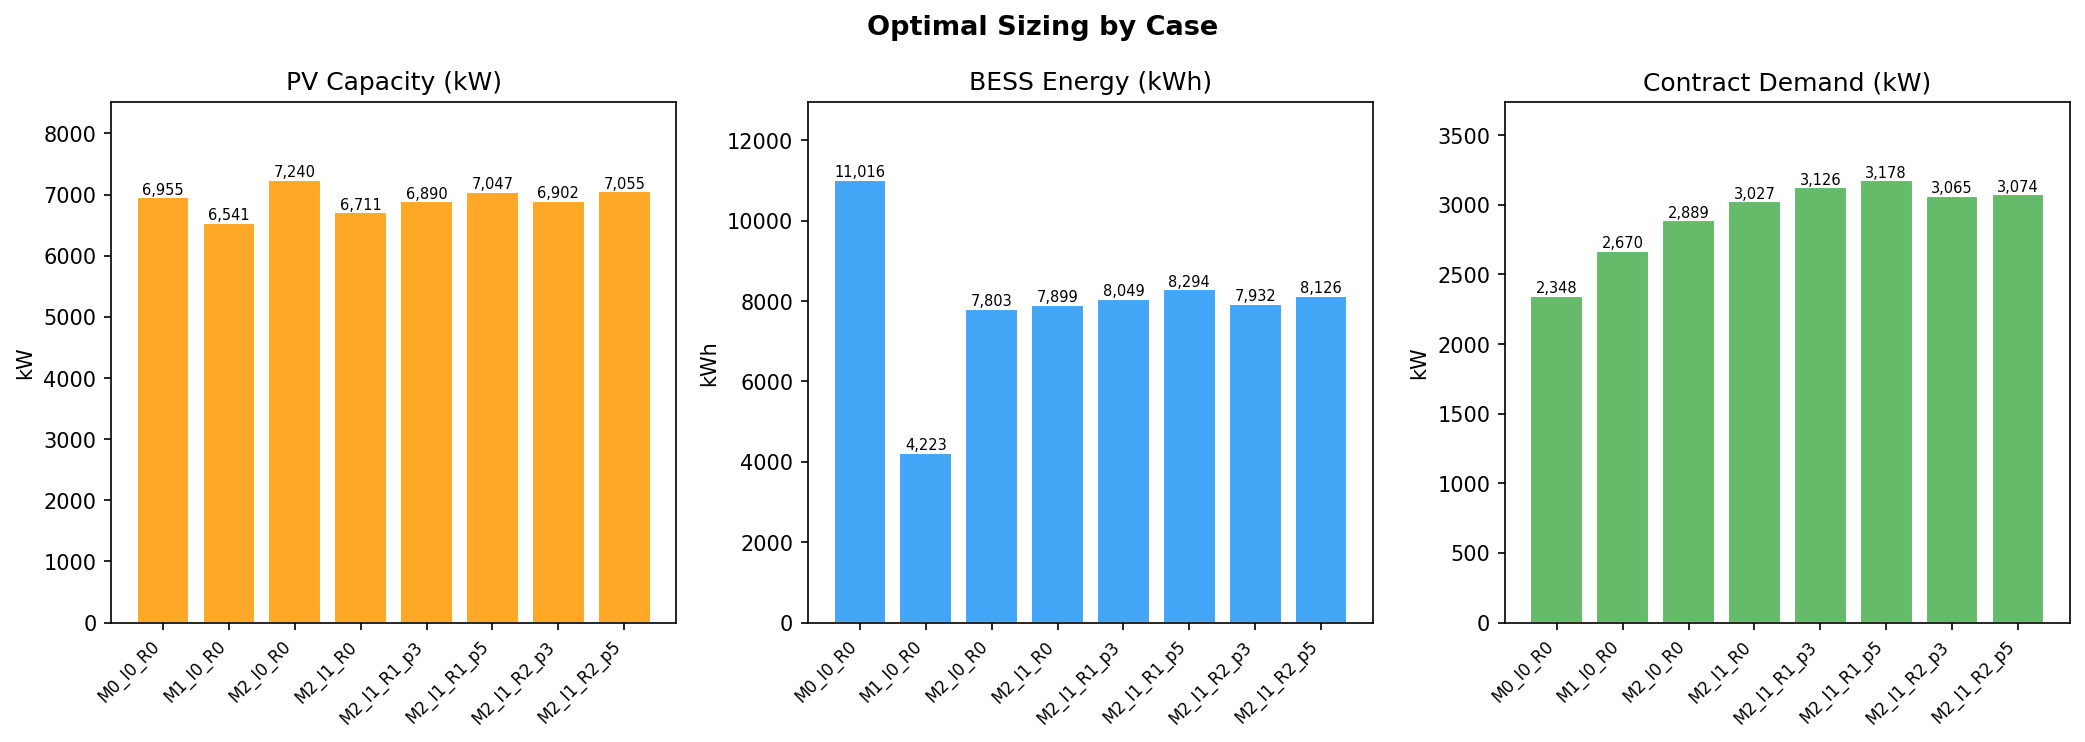

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# PV
axes[0].bar(cases['case'], cases['pv_kw'], color='#FFA726', edgecolor='white')
axes[0].set_title('PV Capacity (kW)')
axes[0].set_ylabel('kW')
for i, v in enumerate(cases['pv_kw']): axes[0].text(i, v+50, f'{v:,.0f}', ha='center', fontsize=7)

# BESS Energy
axes[1].bar(cases['case'], cases['bess_e_kwh'], color='#42A5F5', edgecolor='white')
axes[1].set_title('BESS Energy (kWh)')
axes[1].set_ylabel('kWh')
for i, v in enumerate(cases['bess_e_kwh']): axes[1].text(i, v+80, f'{v:,.0f}', ha='center', fontsize=7)

# Contract Demand
axes[2].bar(cases['case'], cases['contract_kw'], color='#66BB6A', edgecolor='white')
axes[2].set_title('Contract Demand (kW)')
axes[2].set_ylabel('kW')
for i, v in enumerate(cases['contract_kw']): axes[2].text(i, v+20, f'{v:,.0f}', ha='center', fontsize=7)

for ax in axes:
    ax.set_xticklabels(cases['case'], rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
plt.suptitle('Optimal Sizing by Case', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(out / 'fig3_sizing_comparison.png')
plt.show()

## Figure 4 — RE Fraction Achieved

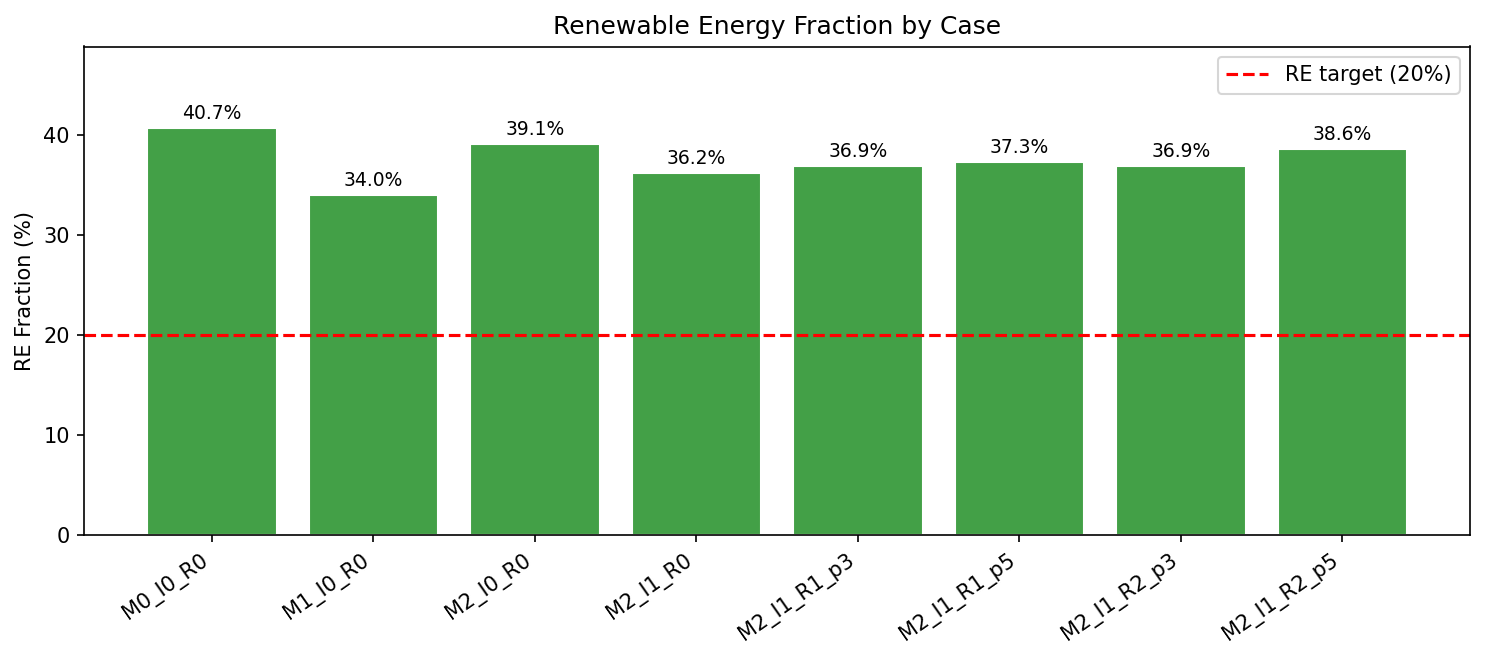

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(cases['case'], cases['re_pct'], color='#43A047', edgecolor='white')
ax.axhline(20, color='red', ls='--', lw=1.5, label='RE target (20%)')
for bar, val in zip(bars, cases['re_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('RE Fraction (%)')
ax.set_title('Renewable Energy Fraction by Case')
ax.legend()
ax.set_ylim(0, cases['re_pct'].max() * 1.2)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(out / 'fig4_re_fraction.png')
plt.show()

## Figure 5 — E/P Ratio and BESS Power

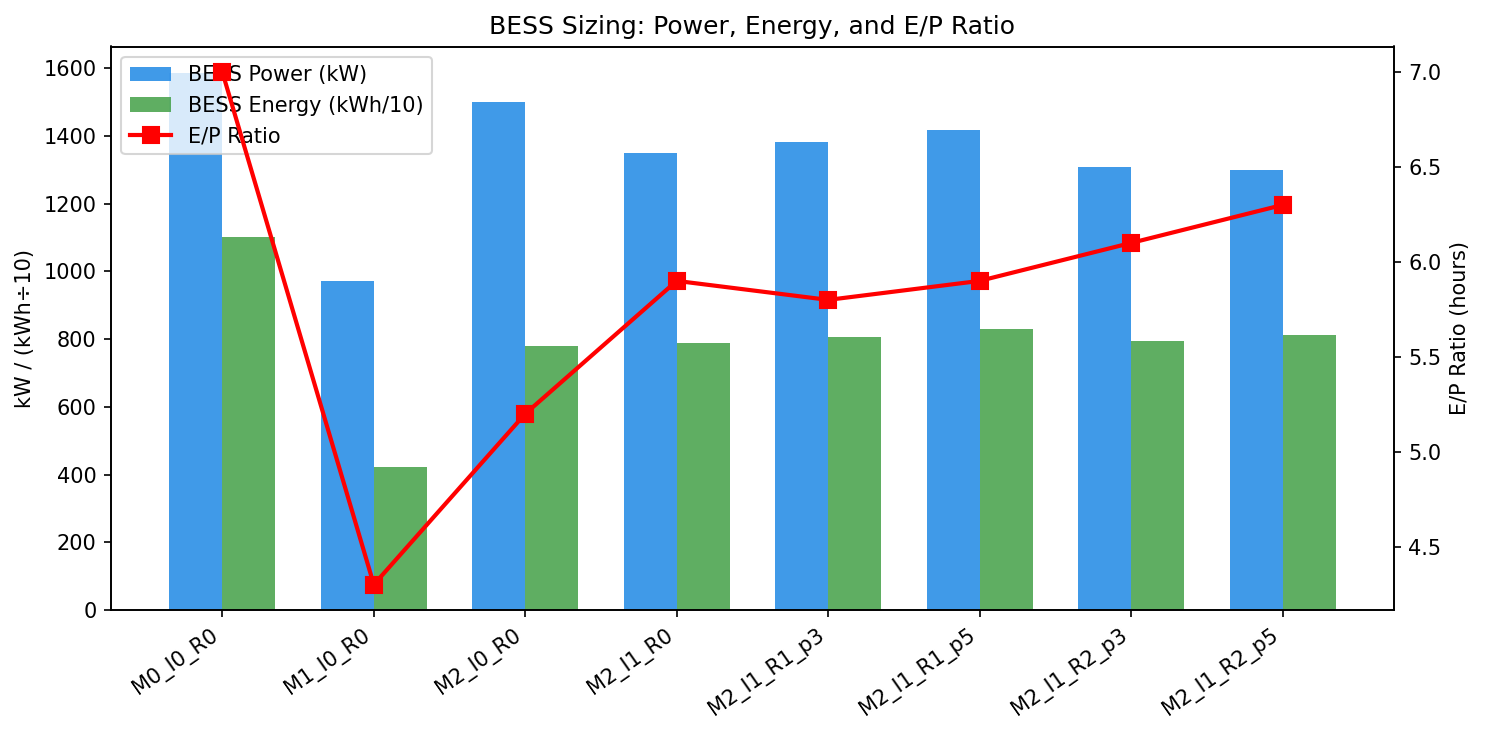

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
x = np.arange(len(cases))
w = 0.35
ax1.bar(x - w/2, cases['bess_p_kw'], w, color='#1E88E5', label='BESS Power (kW)', alpha=0.85)
ax1.bar(x + w/2, cases['bess_e_kwh']/10, w, color='#43A047', label='BESS Energy (kWh/10)', alpha=0.85)
ax2.plot(x, cases['ep_ratio'], 'rs-', ms=8, lw=2, label='E/P Ratio')
ax1.set_xticks(x)
ax1.set_xticklabels(cases['case'], rotation=35, ha='right')
ax1.set_ylabel('kW / (kWh÷10)')
ax2.set_ylabel('E/P Ratio (hours)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('BESS Sizing: Power, Energy, and E/P Ratio')
plt.tight_layout()
plt.savefig(out / 'fig5_bess_ep_ratio.png')
plt.show()

## Figure 6 — Bridge Comparison: v1 (spec v3, 95 repdays) vs v7 (44 repdays)

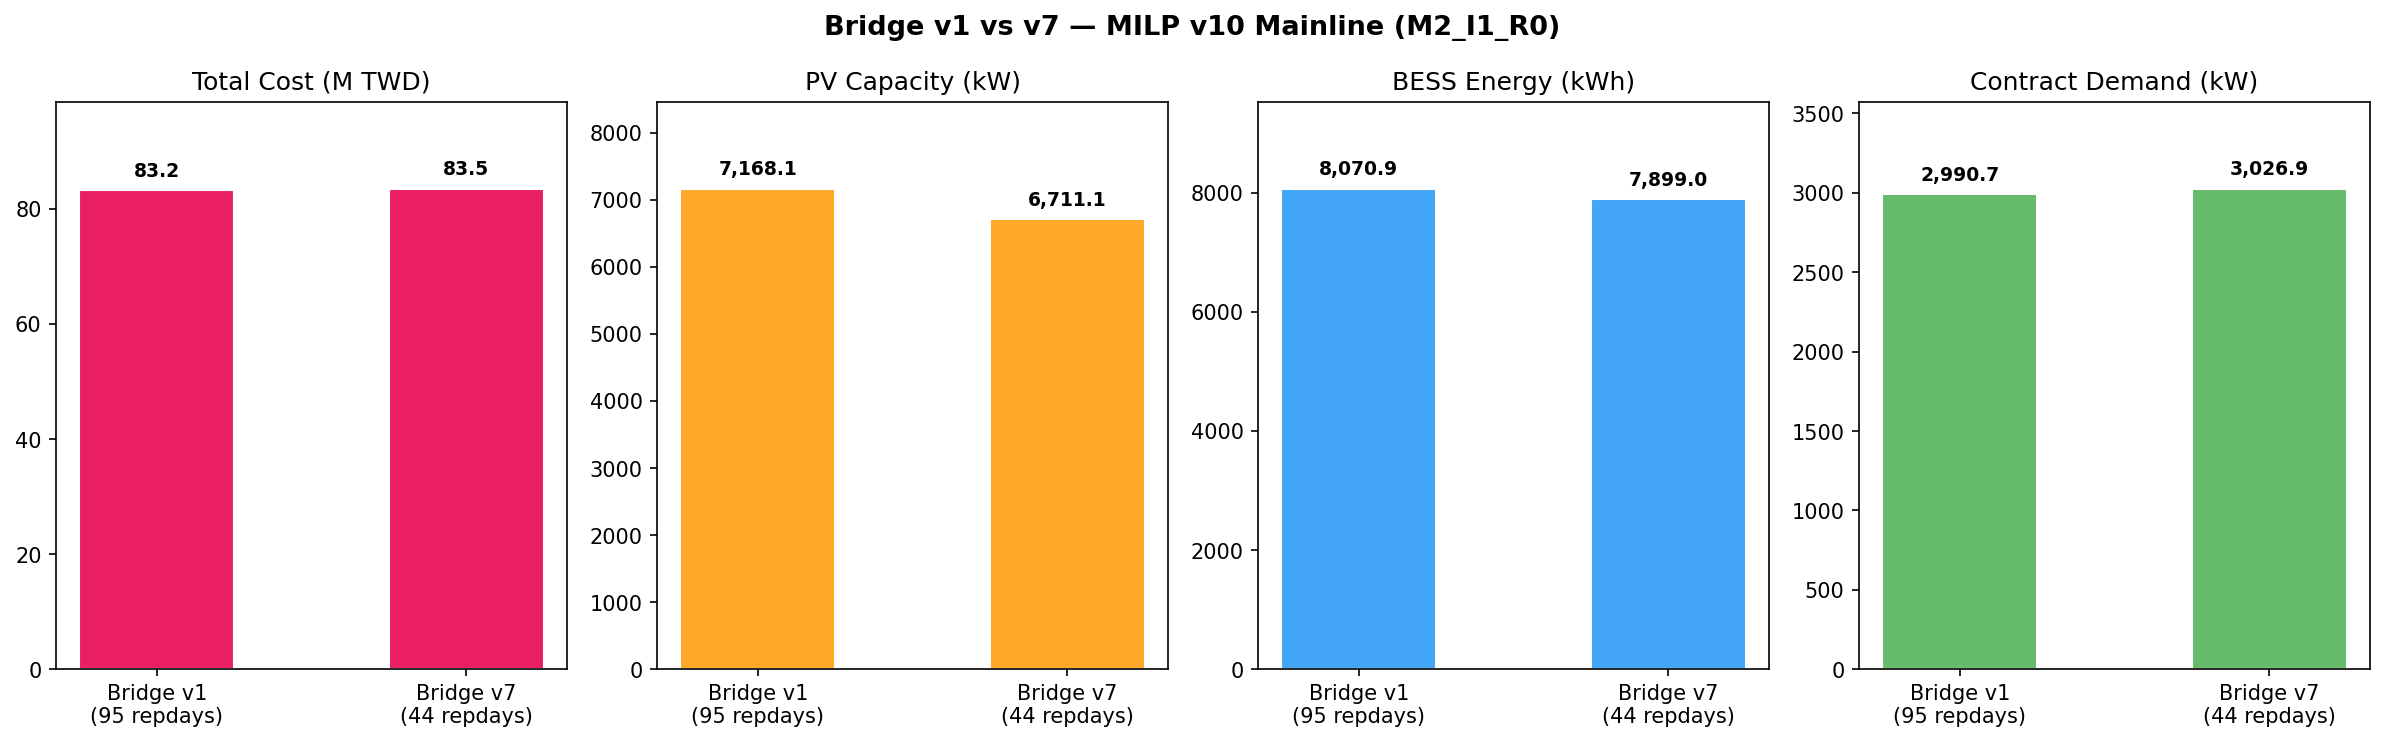

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics = [
    ('total_cost_M', 'Total Cost (M TWD)', '#E91E63'),
    ('pv_kw', 'PV Capacity (kW)', '#FFA726'),
    ('bess_e_kwh', 'BESS Energy (kWh)', '#42A5F5'),
    ('contract_kw', 'Contract Demand (kW)', '#66BB6A'),
]
labels = ['Bridge v1\n(95 repdays)', 'Bridge v7\n(44 repdays)']
for ax, (col, title, color) in zip(axes, metrics):
    vals = bridge[col].values
    bars = ax.bar(labels, vals, color=color, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{v:,.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.18)
plt.suptitle('Bridge v1 vs v7 — MILP v10 Mainline (M2_I1_R0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(out / 'fig6_bridge_comparison.png')
plt.show()

In [8]:
# Percentage differences
v1 = bridge.iloc[0]
v7 = bridge.iloc[1]
print('Bridge v1 vs v7 — Percentage Differences:')
for col in ['total_cost_M', 'pv_kw', 'bess_e_kwh', 'bess_p_kw', 'contract_kw', 're_pct', 'solve_s']:
    d = (v7[col] - v1[col]) / v1[col] * 100
    print(f'  {col:>15s}: v1={v1[col]:>10.1f}  v7={v7[col]:>10.1f}  Δ={d:>+6.1f}%')
print(f'\nSolve time speedup: {v1["solve_s"]/v7["solve_s"]:.1f}x')

Bridge v1 vs v7 — Percentage Differences:
     total_cost_M: v1=      83.2  v7=      83.5  Δ=  +0.3%
            pv_kw: v1=    7168.1  v7=    6711.1  Δ=  -6.4%
       bess_e_kwh: v1=    8070.9  v7=    7899.0  Δ=  -2.1%
        bess_p_kw: v1=    1423.8  v7=    1350.0  Δ=  -5.2%
      contract_kw: v1=    2990.7  v7=    3026.9  Δ=  +1.2%
           re_pct: v1=      39.0  v7=      36.2  Δ=  -7.2%
          solve_s: v1=      33.7  v7=      25.5  Δ= -24.3%

Solve time speedup: 1.3x


## Figure 7 — Robustness Uplift: Cost Impact

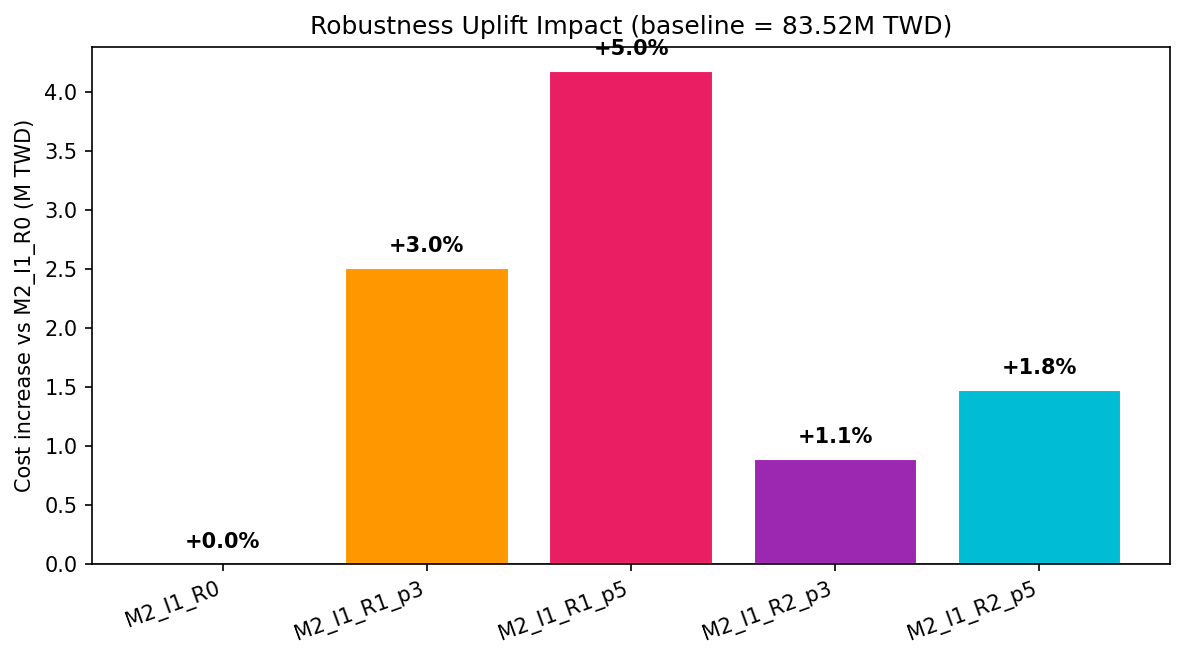

In [9]:
baseline = cases[cases['case'] == 'M2_I1_R0']['total_cost_M'].values[0]
rob = cases[cases['case'].str.startswith('M2_I1_R')].copy()
rob['delta_M'] = rob['total_cost_M'] - baseline
rob['delta_pct'] = rob['delta_M'] / baseline * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
colors_r = ['#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
bars = ax.bar(rob['case'], rob['delta_M'], color=colors_r[:len(rob)], edgecolor='white')
for bar, pct in zip(bars, rob['delta_pct']):
    ht = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, ht + 0.1, f'+{pct:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Cost increase vs M2_I1_R0 (M TWD)')
ax.set_title(f'Robustness Uplift Impact (baseline = {baseline:.2f}M TWD)')
ax.axhline(0, color='gray', lw=0.8)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(out / 'fig7_robustness_uplift.png')
plt.show()

## Figure 8 — Feature Progression (M0→M1→M2→M2+I1)

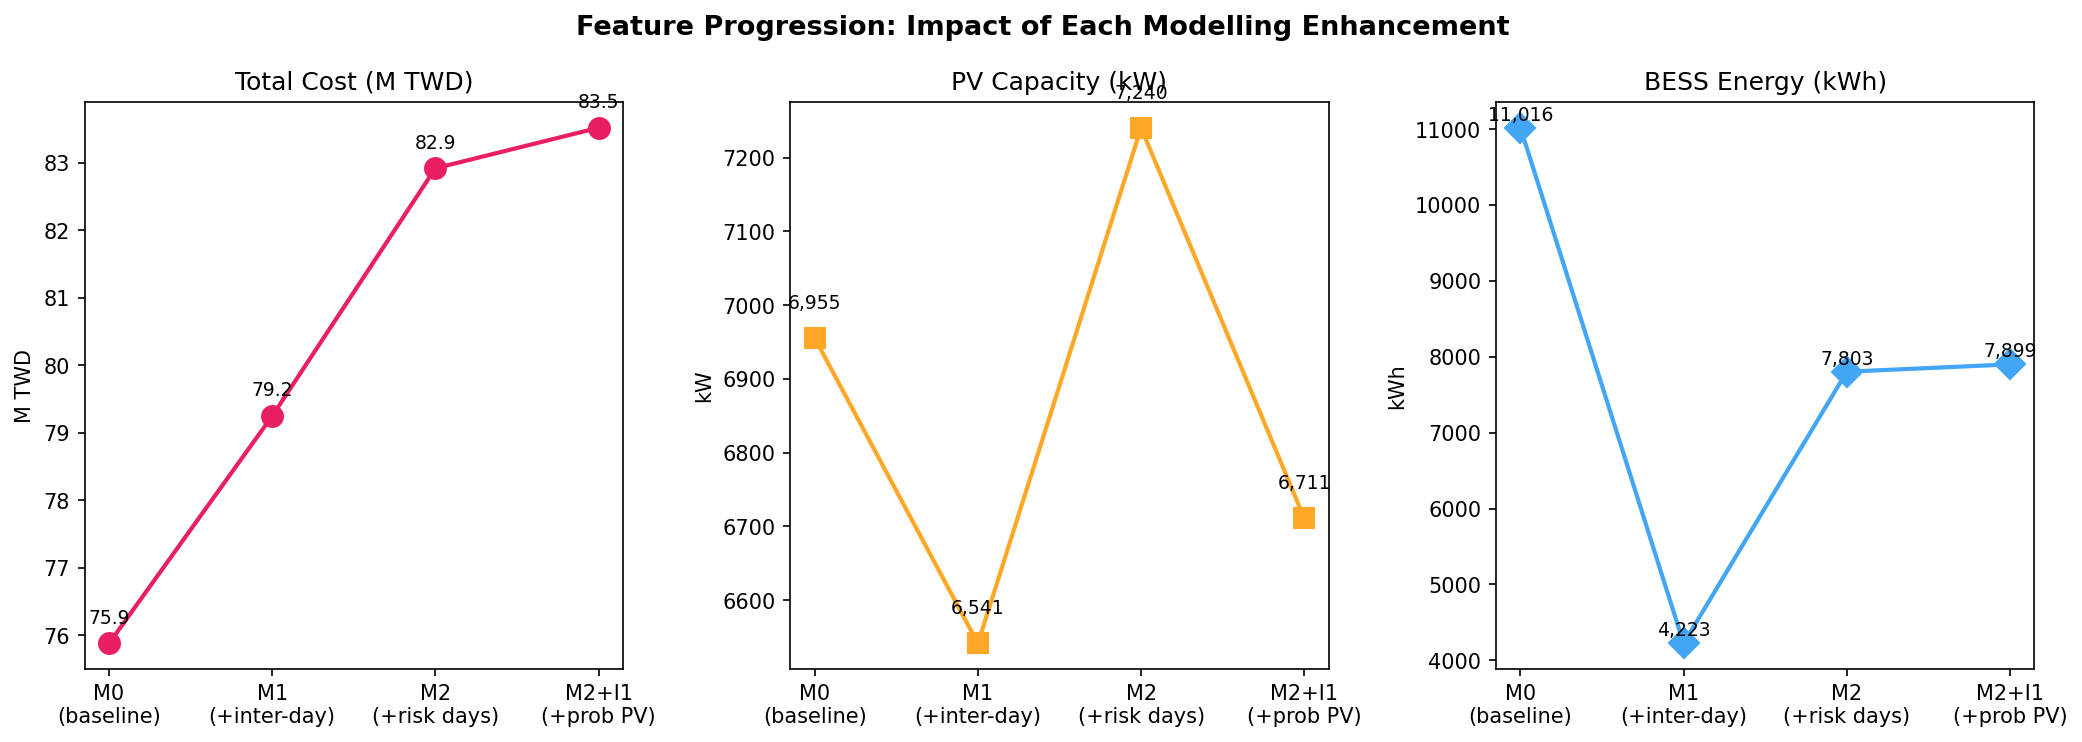

In [10]:
prog = cases[cases['case'].isin(['M0_I0_R0','M1_I0_R0','M2_I0_R0','M2_I1_R0'])].copy()
labels_prog = ['M0\n(baseline)', 'M1\n(+inter-day)', 'M2\n(+risk days)', 'M2+I1\n(+prob PV)']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].plot(labels_prog, prog['total_cost_M'].values, 'o-', color='#E91E63', lw=2, ms=10)
for i, v in enumerate(prog['total_cost_M']): axes[0].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)
axes[0].set_title('Total Cost (M TWD)')
axes[0].set_ylabel('M TWD')

axes[1].plot(labels_prog, prog['pv_kw'].values, 's-', color='#FFA726', lw=2, ms=10)
for i, v in enumerate(prog['pv_kw']): axes[1].text(i, v+40, f'{v:,.0f}', ha='center', fontsize=9)
axes[1].set_title('PV Capacity (kW)')
axes[1].set_ylabel('kW')

axes[2].plot(labels_prog, prog['bess_e_kwh'].values, 'D-', color='#42A5F5', lw=2, ms=10)
for i, v in enumerate(prog['bess_e_kwh']): axes[2].text(i, v+100, f'{v:,.0f}', ha='center', fontsize=9)
axes[2].set_title('BESS Energy (kWh)')
axes[2].set_ylabel('kWh')

plt.suptitle('Feature Progression: Impact of Each Modelling Enhancement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(out / 'fig8_feature_progression.png')
plt.show()

## Summary Table

In [11]:
print('\n' + '='*80)
print('  STO-MILP v10 — 8-Case Summary')
print('='*80)
print(cases.to_string(index=False))
print('\n' + '='*80)
print('  Bridge Comparison (M2_I1_R0 mainline)')
print('='*80)
print(bridge.to_string(index=False))
print('\nAll figures saved to milp_outputs/')


  STO-MILP v10 — 8-Case Summary
       case  pv_kw  bess_p_kw  bess_e_kwh  ep_ratio  contract_kw  total_cost_M  invest_M  opex_M  trec_M  re_pct  solve_s
   M0_I0_R0 6955.3     1584.6     11016.2       7.0       2347.6         75.88     39.51   36.37     0.0    40.7      0.2
   M1_I0_R0 6541.4      970.8      4222.7       4.3       2669.9         79.25     32.75   46.49     0.0    34.0      3.3
   M2_I0_R0 7240.5     1501.3      7802.7       5.2       2888.9         82.92     39.14   43.78     0.0    39.1      9.3
   M2_I1_R0 6711.1     1350.0      7899.0       5.9       3026.9         83.52     37.72   45.80     0.0    36.2     25.9
M2_I1_R1_p3 6890.0     1381.1      8049.2       5.8       3126.3         86.03     38.72   47.31     0.0    36.9     55.3
M2_I1_R1_p5 7046.6     1417.5      8293.9       5.9       3178.3         87.70     39.60   48.10     0.0    37.3     44.7
M2_I1_R2_p3 6901.5     1308.4      7932.1       6.1       3064.9         84.41     38.41   46.00     0.0    36.9 